In [13]:
import pandas as pd
import numpy as np

# تحميل الملفات الأساسية
orders = pd.read_csv(r'C:\Users\nagy\OneDrive\Desktop\archive\olist_orders_dataset.csv')
items = pd.read_csv(r'C:\Users\nagy\OneDrive\Desktop\archive\olist_order_items_dataset.csv')
customers = pd.read_csv(r'C:\Users\nagy\OneDrive\Desktop\archive\olist_customers_dataset.csv')
products = pd.read_csv(r'C:\Users\nagy\OneDrive\Desktop\archive\olist_products_dataset.csv')
payments = pd.read_csv(r'C:\Users\nagy\OneDrive\Desktop\archive\olist_order_payments_dataset.csv')

# أول نظرة على كل ملف
for name, df in {'orders': orders, 'items': items, 
                  'customers': customers, 'products': products,
                  'payments': payments}.items():
    print(f"\n{'='*40}")
    print(f"Dataset: {name}")
    print(f"الشكل: {df.shape[0]} صف × {df.shape[1]} عمود")
    print(f"\nالأعمدة:\n{df.dtypes}")
    print(f"\nالقيم الناقصة:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Dataset: orders
الشكل: 99441 صف × 8 عمود

الأعمدة:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

القيم الناقصة:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Dataset: items
الشكل: 112650 صف × 7 عمود

الأعمدة:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

القيم الناقصة:
Series([], dtype: int64)

Dataset: customers
الشكل: 99441 صف × 5 عمود

الأعمدة:
customer_id                 object
customer_unique_id          object
customer_zip_code_pref

In [14]:
# 1. تحويل التواريخ من نص لـ datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# 2. شوف توزيع حالات الطلبات
print("حالات الطلبات:")
print(orders['order_status'].value_counts())

# 3. احتفظ بس بالطلبات المكتملة للتحليل
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

# 4. شيك على القيم الناقصة في التواريخ
print(f"\nطلبات بدون تاريخ توصيل: {orders_clean['order_delivered_customer_date'].isnull().sum()}")

# 5. احذف الصفوف اللي مفيهاش تاريخ توصيل
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])

print(f"\nعدد الطلبات المكتملة النظيفة: {len(orders_clean)}")

حالات الطلبات:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

طلبات بدون تاريخ توصيل: 8

عدد الطلبات المكتملة النظيفة: 96470


In [15]:
# تنظيف جدول المنتجات
print("قيم ناقصة في المنتجات:")
print(products.isnull().sum())

# ملء الفئات الناقصة بـ 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')

# دمج الجداول الأساسية مع بعض
df_main = orders_clean.merge(items, on='order_id', how='left')
df_main = df_main.merge(products[['product_id','product_category_name']], 
                         on='product_id', how='left')
df_main = df_main.merge(payments[['order_id','payment_value']]
                         .groupby('order_id').sum().reset_index(),
                         on='order_id', how='left')
df_main = df_main.merge(customers[['customer_id','customer_state']], 
                         on='customer_id', how='left')

print(f"\nالجدول الموحد: {df_main.shape[0]} صف × {df_main.shape[1]} عمود")
print(f"\nأعمدة الجدول:\n{df_main.columns.tolist()}")


قيم ناقصة في المنتجات:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

الجدول الموحد: 110189 صف × 17 عمود

أعمدة الجدول:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'payment_value', 'customer_state']


In [16]:
# استخراج معلومات الوقت
df_main['order_year'] = df_main['order_purchase_timestamp'].dt.year
df_main['order_month'] = df_main['order_purchase_timestamp'].dt.month
df_main['order_month_name'] = df_main['order_purchase_timestamp'].dt.strftime('%Y-%m')

# حساب وقت التوصيل بالأيام
df_main['delivery_days'] = (
    df_main['order_delivered_customer_date'] - 
    df_main['order_purchase_timestamp']
).dt.days

# شيك نهائي
print("ملخص الجدول النهائي:")
print(df_main.describe())

# حفظ البيانات النظيفة
df_main.to_csv('olist_clean.csv', index=False)
print("\nتم الحفظ بنجاح — olist_clean.csv جاهز للتحليل!")


ملخص الجدول النهائي:
            order_purchase_timestamp              order_approved_at  \
count                         110189                         110174   
mean   2018-01-02 02:39:32.673823744  2018-01-02 14:13:43.955089152   
min              2016-09-15 12:16:38            2016-09-15 12:16:38   
25%              2017-09-15 04:48:38     2017-09-15 14:55:25.500000   
50%              2018-01-21 09:13:44            2018-01-22 13:57:07   
75%              2018-05-05 15:38:37  2018-05-05 22:47:36.249999872   
max              2018-08-29 15:00:37            2018-08-29 15:10:26   
std                              NaN                            NaN   

       order_delivered_customer_date  order_estimated_delivery_date  \
count                         110189                         110189   
mean   2018-01-14 13:59:34.689261056  2018-01-25 21:57:38.403289088   
min              2016-10-11 13:46:32            2016-10-04 00:00:00   
25%              2017-09-26 20:15:35            2017-10

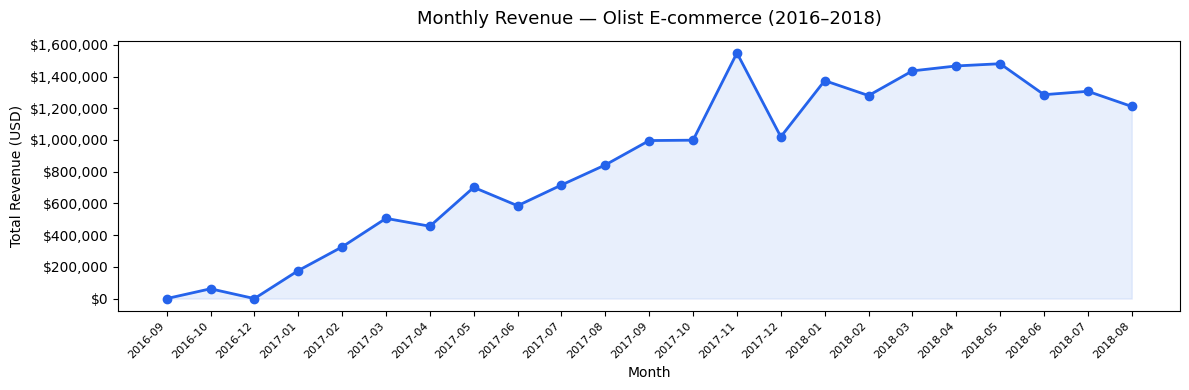

✅ monthly_sales.png saved


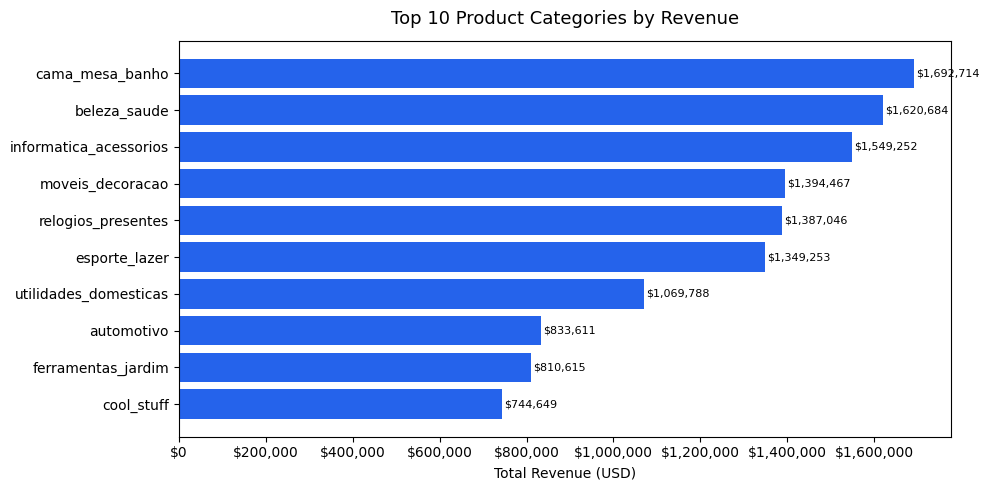

✅ top_categories.png saved


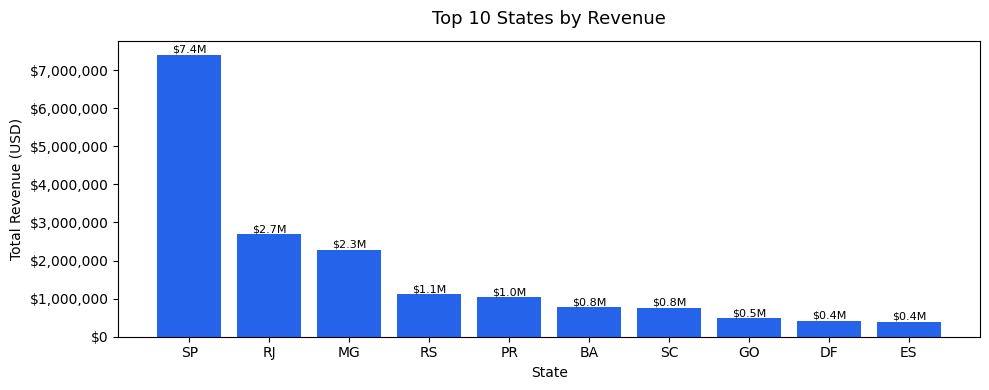

✅ top_states.png saved


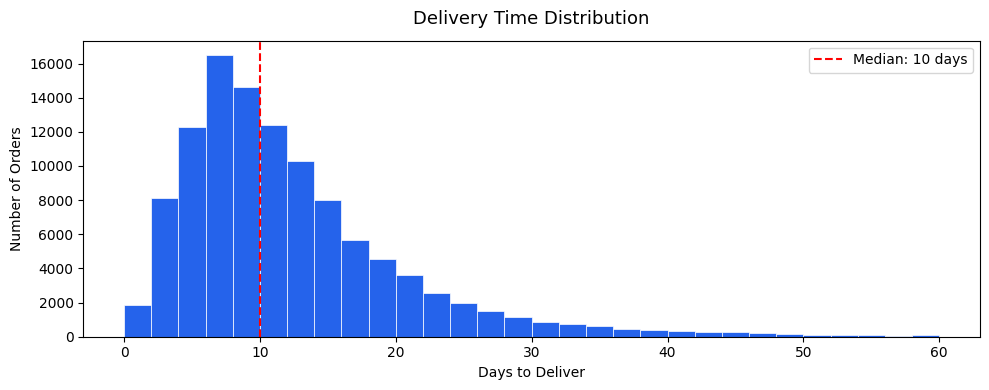

✅ delivery_distribution.png saved

Quick Analysis Summary:
Total Revenue:              $  19,774,782
Average Order Value:        $      179.47
Top Product Category:       cama_mesa_banho
Top State by Revenue:       SP
Median Delivery Time:       10 days
Orders delayed +30 days:    4,558 orders


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('olist_clean.csv', parse_dates=['order_purchase_timestamp'])

# ===== 1. Monthly Sales =====
monthly = (df.groupby('order_month_name')['payment_value']
             .sum()
             .reset_index()
             .sort_values('order_month_name'))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['order_month_name'], monthly['payment_value'],
        marker='o', linewidth=2, color='#2563EB')
ax.fill_between(range(len(monthly)), monthly['payment_value'], alpha=0.1, color='#2563EB')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['order_month_name'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Monthly Revenue — Olist E-commerce (2016–2018)', fontsize=13, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (USD)')
plt.tight_layout()
plt.savefig('monthly_sales.png', dpi=150)
plt.show()
print("✅ monthly_sales.png saved")

# ===== 2. Top 10 Product Categories =====
top_cats = (df.groupby('product_category_name')['payment_value']
              .sum()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_cats['product_category_name'][::-1],
               top_cats['payment_value'][::-1], color='#2563EB')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Top 10 Product Categories by Revenue', fontsize=13, pad=12)
ax.set_xlabel('Total Revenue (USD)')
for bar, val in zip(bars, top_cats['payment_value'][::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150)
plt.show()
print("✅ top_categories.png saved")

# ===== 3. Top 10 States by Revenue =====
top_states = (df.groupby('customer_state')
                .agg(total_revenue=('payment_value','sum'),
                     order_count=('order_id','count'))
                .sort_values('total_revenue', ascending=False)
                .head(10)
                .reset_index())

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(top_states['customer_state'], top_states['total_revenue'], color='#2563EB')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Top 10 States by Revenue', fontsize=13, pad=12)
ax.set_xlabel('State')
ax.set_ylabel('Total Revenue (USD)')
for bar, val in zip(bars, top_states['total_revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'${val/1e6:.1f}M', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('top_states.png', dpi=150)
plt.show()
print("✅ top_states.png saved")

# ===== 4. Delivery Time Distribution =====
df_delivery = df[df['delivery_days'].between(0, 60)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_delivery['delivery_days'], bins=30, color='#2563EB', edgecolor='white', linewidth=0.5)
ax.axvline(df['delivery_days'].median(), color='red', linestyle='--', linewidth=1.5,
           label=f"Median: {df['delivery_days'].median():.0f} days")
ax.set_title('Delivery Time Distribution', fontsize=13, pad=12)
ax.set_xlabel('Days to Deliver')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('delivery_distribution.png', dpi=150)
plt.show()
print("✅ delivery_distribution.png saved")

# ===== Summary =====
print("\n" + "="*45)
print("Quick Analysis Summary:")
print("="*45)
print(f"Total Revenue:              ${df['payment_value'].sum():>12,.0f}")
print(f"Average Order Value:        ${df['payment_value'].mean():>12,.2f}")
print(f"Top Product Category:       {top_cats.iloc[0]['product_category_name']}")
print(f"Top State by Revenue:       {top_states.iloc[0]['customer_state']}")
print(f"Median Delivery Time:       {df['delivery_days'].median():.0f} days")
print(f"Orders delayed +30 days:    {(df['delivery_days'] > 30).sum():,} orders")

In [20]:
import pandas as pd

df = pd.read_csv('olist_clean.csv', parse_dates=['order_purchase_timestamp'])

# ===== Sheet 1: Monthly Revenue =====
monthly = (df.groupby('order_month_name')
             .agg(
                 total_revenue=('payment_value', 'sum'),
                 total_orders=('order_id', 'count'),
                 avg_order_value=('payment_value', 'mean')
             )
             .reset_index()
             .sort_values('order_month_name'))
monthly.columns = ['Month', 'Total Revenue', 'Total Orders', 'Avg Order Value']
monthly['Total Revenue'] = monthly['Total Revenue'].round(2)
monthly['Avg Order Value'] = monthly['Avg Order Value'].round(2)

# ===== Sheet 2: Top Categories =====
categories = (df.groupby('product_category_name')
                .agg(
                    total_revenue=('payment_value', 'sum'),
                    total_orders=('order_id', 'count'),
                    avg_price=('price', 'mean')
                )
                .sort_values('total_revenue', ascending=False)
                .head(15)
                .reset_index())
categories.columns = ['Category', 'Total Revenue', 'Total Orders', 'Avg Price']
categories['Total Revenue'] = categories['Total Revenue'].round(2)
categories['Avg Price'] = categories['Avg Price'].round(2)

# ===== Sheet 3: States Performance =====
states = (df.groupby('customer_state')
            .agg(
                total_revenue=('payment_value', 'sum'),
                total_orders=('order_id', 'count'),
                avg_delivery_days=('delivery_days', 'mean'),
                late_orders=('delivery_days', lambda x: (x > 30).sum())
            )
            .sort_values('total_revenue', ascending=False)
            .reset_index())
states.columns = ['State', 'Total Revenue', 'Total Orders', 
                  'Avg Delivery Days', 'Late Orders (+30d)']
states['Total Revenue'] = states['Total Revenue'].round(2)
states['Avg Delivery Days'] = states['Avg Delivery Days'].round(1)

# ===== Export to Excel =====
with pd.ExcelWriter('olist_dashboard_data.xlsx', engine='openpyxl') as writer:
    monthly.to_excel(writer, sheet_name='Monthly Revenue', index=False)
    categories.to_excel(writer, sheet_name='Top Categories', index=False)
    states.to_excel(writer, sheet_name='States Performance', index=False)

print("✅ olist_dashboard_data.xlsx saved successfully!")
print(f"\nSheet 1 — Monthly Revenue:     {len(monthly)} rows")
print(f"Sheet 2 — Top Categories:      {len(categories)} rows")
print(f"Sheet 3 — States Performance:  {len(states)} rows")

# ===== Quick validation =====
print("\n--- Monthly Revenue Preview ---")
print(monthly.tail(3).to_string(index=False))
print("\n--- Top 5 Categories ---")
print(categories.head(5)[['Category','Total Revenue','Total Orders']].to_string(index=False))

✅ olist_dashboard_data.xlsx saved successfully!

Sheet 1 — Monthly Revenue:     23 rows
Sheet 2 — Top Categories:      15 rows
Sheet 3 — States Performance:  27 rows

--- Monthly Revenue Preview ---
  Month  Total Revenue  Total Orders  Avg Order Value
2018-06     1285396.78          7007           183.44
2018-07     1306707.42          6960           187.75
2018-08     1211240.09          7142           169.59

--- Top 5 Categories ---
              Category  Total Revenue  Total Orders
       cama_mesa_banho     1692714.28         10953
          beleza_saude     1620684.04          9465
informatica_acessorios     1549252.47          7643
      moveis_decoracao     1394466.93          8160
    relogios_presentes     1387046.31          5857


In [19]:
pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\nagy\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
